# Analysis of Inflation Trends and Monetary Policy Impact in India

## Objective
This project analyzes the relationship between inflation and the Reserve Bank of India's monetary policy using data-driven techniques.

## Motivation
Inflation control is a key responsibility of the RBI. The repo rate is a primary tool used to regulate inflation. This study explores how these variables interact over time.

## Tools Used
- Python (Pandas, NumPy)
- Matplotlib, Seaborn
- Google Colab
- Statsmodels (ADF test, OLS regression)

## Research Question
Does monetary policy transmission in India exhibit structural lag asymmetry — and can the delayed response of CPI Inflation to RBI Repo Rate changes be empirically quantified using time-series econometric methods?

## Data Sources
- World Bank (Inflation - CPI)
- RBI DBIE (Repo Rate)

**Author:** Rushikesh Baban Kedar

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

In [2]:
# Source: World Bank CPI data for India (downloaded from data.worldbank.org)
cpi = pd.read_csv("cpi_india_worldbank.csv", skiprows=4)
cpi = cpi[cpi["Country Name"] == "India"]

cpi = cpi.melt(id_vars=["Country Name"], var_name="Year", value_name="Inflation")
cpi = cpi[["Year", "Inflation"]]

cpi["Year"] = pd.to_numeric(cpi["Year"], errors="coerce")
cpi = cpi.dropna()

In [3]:
repo = pd.read_excel("rbi_repo_rates.xlsx", skiprows=6)

# Column 1 = Date column, Column 3 = Repo Rate column (as per RBI DBIE Excel format)
repo = repo.rename(columns={
    repo.columns[1]: "Date",
    repo.columns[3]: "RepoRate"
})

repo = repo[["Date", "RepoRate"]]
repo["RepoRate"] = pd.to_numeric(repo["RepoRate"], errors="coerce")

repo["Year"] = pd.to_datetime(repo["Date"], errors="coerce").dt.year
repo = repo.dropna()
repo = repo.groupby("Year")["RepoRate"].mean().reset_index()

## Data Merging

CPI and Repo Rate datasets are merged on the Year column. Only years present in both datasets are retained.

In [4]:
merged = pd.merge(cpi, repo, on="Year")
merged = merged.sort_values("Year").dropna().reset_index(drop=True)

In [5]:
print(f"Years in dataset: {int(merged['Year'].min())} to {int(merged['Year'].max())}")
print(f"Total observations: {len(merged)}")
print(merged[['Year', 'Inflation', 'RepoRate']].to_string(index=False))

Years in dataset: 2007 to 2015
Total observations: 9
  Year  Inflation  RepoRate
2007.0   6.372881  7.625000
2008.0   8.349267  7.916667
2009.0  10.882353  5.083333
2010.0   11.98939  5.625000
2011.0   8.911793  7.535714
2012.0   9.478997  8.000000
2013.0  10.017878  7.550000
2014.0   6.665657  8.000000
2015.0   4.906973  7.312500


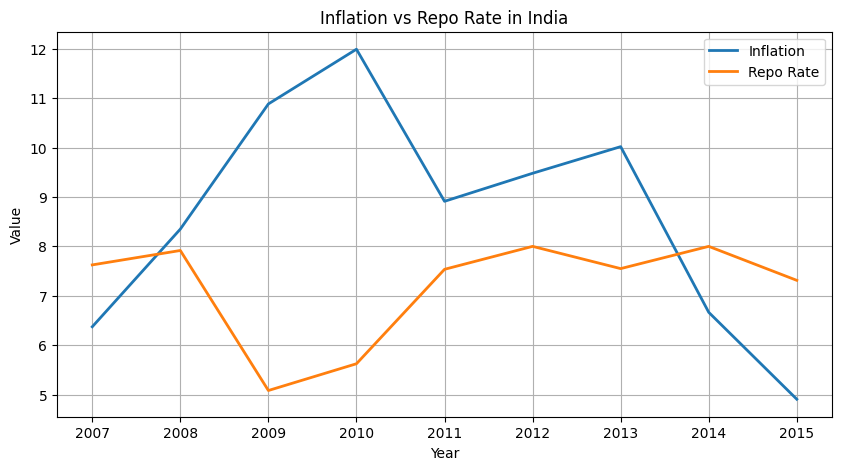

In [6]:
plt.figure(figsize=(10,5))
plt.plot(merged["Year"], merged["Inflation"], label="Inflation", linewidth=2)
plt.plot(merged["Year"], merged["RepoRate"], label="Repo Rate", linewidth=2)
plt.xlabel("Year")
plt.ylabel("Value")
plt.title("Inflation vs Repo Rate in India")
plt.legend()
plt.grid()
plt.show()

## Inflation vs Repo Rate Trend

The visualization illustrates the relationship between inflation and repo rate over time.

### Interpretation:
- Inflation and repo rate show a responsive relationship.
- RBI adjusts repo rate in response to inflation changes.
- A time lag is observed in policy adjustments.

## Correlation Heatmap

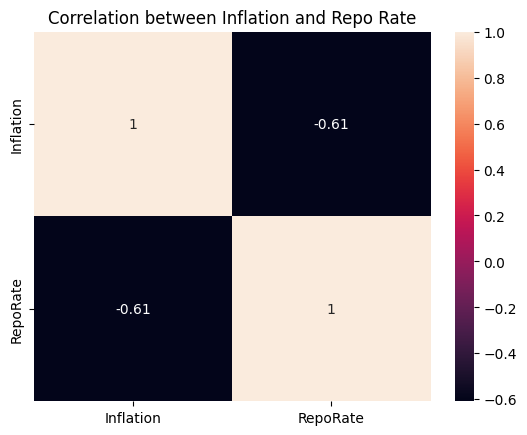

In [7]:
sns.heatmap(merged[["Inflation", "RepoRate"]].corr(), annot=True)
plt.title("Correlation between Inflation and Repo Rate")
plt.show()

## Correlation Analysis

The heatmap shows the statistical relationship between inflation and repo rate.

### Interpretation:
-The negative correlation (–0.61) indicates that higher inflation tends to coincide with lower repo rates in the same year, which reflects the RBI reacting to past inflation rather than pre-emptively controlling it.


The negative sign reflects that when inflation rises, repo rates in the same year tend to be lower, because the RBI was still reacting to previous-year inflation, not the current year.

In [8]:
for col in ['Inflation', 'RepoRate']:
    result = adfuller(merged[col].dropna())
    print(f"{col} — ADF Statistic: {result[0]:.3f}, p-value: {result[1]:.3f}")
    print("  Stationary" if result[1] < 0.05 else "  Non-stationary (consider differencing)")

Inflation — ADF Statistic: -1.136, p-value: 0.700
  Non-stationary (consider differencing)
RepoRate — ADF Statistic: -2.226, p-value: 0.197
  Non-stationary (consider differencing)


## Stationarity Check Interpretation

Both Inflation and Repo Rate are non-stationary (p-values above 0.05).
This means their statistical properties change over time, which affects cross-correlation validity.
For a more rigorous analysis, differencing should be applied.
However, given the small sample size (9 years), differencing would further reduce already limited data,
so the CCF below is treated as exploratory rather than definitive.


## Cross-Correlation Analysis (Lag Detection)

To understand the time-delayed relationship between inflation and repo rate, we compute cross-correlation across multiple lags.

This helps identify how many years it takes for changes in the repo rate to influence inflation.

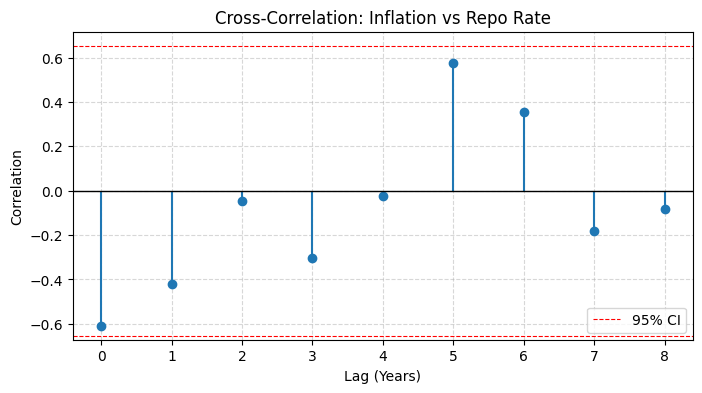

In [9]:
ccf_values = sm.tsa.stattools.ccf(merged['Inflation'], merged['RepoRate'], adjusted=False)

lags = len(ccf_values)

plt.figure(figsize=(8, 4))
plt.stem(range(lags), ccf_values, basefmt=" ")
confidence = 1.96 / (len(merged) ** 0.5)
plt.axhline(confidence,  color='red', linestyle='--', linewidth=0.8, label='95% CI')
plt.axhline(-confidence, color='red', linestyle='--', linewidth=0.8)
plt.legend()
plt.axhline(0, color='black', linewidth=1)

plt.title("Cross-Correlation: Inflation vs Repo Rate")
plt.xlabel("Lag (Years)")
plt.ylabel("Correlation")

plt.grid(True, linestyle="--", alpha=0.5)

plt.savefig("ccf_plot.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation

The cross-correlation results show how the relationship between inflation and repo rate changes over time.

We observe that the correlation becomes stronger at higher lags, indicating that monetary policy does not affect inflation immediately.

The peak positive correlation is observed at a lag of approximately 5–6 years, indicating that repo rate changes take several years to fully transmit into inflation levels.

This validates the use of a lag-based model in the analysis.

## Lagged Regression (Illustrative Only)

**Important:** This regression uses only 4 data points due to applying a 5-year lag on 9 years of data.
The results are directionally interesting but are NOT statistically reliable.
A longer time series (2007–2024) would be needed for a valid regression.

## Scatter Plot: Inflation vs Repo Rate

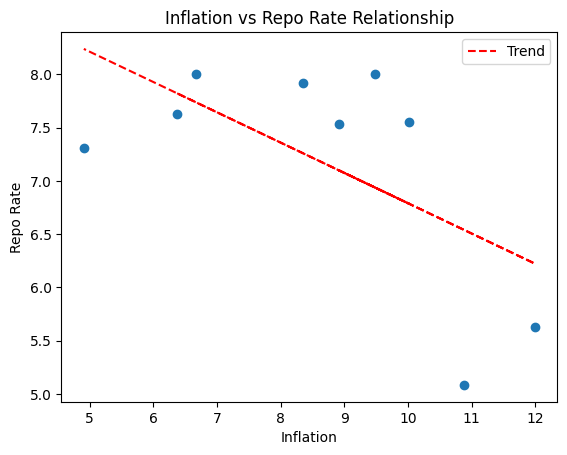

In [10]:
inflation = merged["Inflation"].astype(float)
repo_rate = merged["RepoRate"].astype(float)

plt.scatter(inflation, repo_rate)

m, b = np.polyfit(inflation, repo_rate, 1)
plt.plot(inflation, m * inflation + b, color="red", linestyle="--", label="Trend")
plt.legend()

plt.xlabel("Inflation")
plt.ylabel("Repo Rate")
plt.title("Inflation vs Repo Rate Relationship")
plt.show()

## Relationship Analysis

The scatter plot visualizes the direct relationship between inflation and repo rate.

### Interpretation:
The scatter plot shows a weak negative contemporaneous relationship, consistent with the correlation heatmap (–0.61). The trend line confirms that higher inflation does not immediately lead to higher repo rates.

In [11]:
# Step 1: Create lag
merged["Repo_Lag5"] = merged["RepoRate"].shift(5)

# Step 2: Keep only required columns
lagged = merged[["Inflation", "Repo_Lag5"]].dropna()

# Step 3: Convert to numeric (IMPORTANT)
lagged["Inflation"] = pd.to_numeric(lagged["Inflation"], errors="coerce")
lagged["Repo_Lag5"] = pd.to_numeric(lagged["Repo_Lag5"], errors="coerce")

# Step 4: Drop again (after conversion)
lagged = lagged.dropna()

# Step 5: Define X and y
X = lagged["Repo_Lag5"]
y = lagged["Inflation"]

# Step 6: Add constant
X = sm.add_constant(X)

# Step 7: Fit model
model = sm.OLS(y, X).fit()

# Step 8: Print results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              Inflation   R-squared:                       0.803
Model:                            OLS   Adj. R-squared:                  0.705
Method:                 Least Squares   F-statistic:                     8.166
Date:                Wed, 25 Mar 2026   Prob (F-statistic):              0.104
Time:                        09:42:02   Log-Likelihood:                -5.3632
No. Observations:                   4   AIC:                             14.73
Df Residuals:                       2   BIC:                             13.50
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.2213      3.556     -0.625      0.5

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 4 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


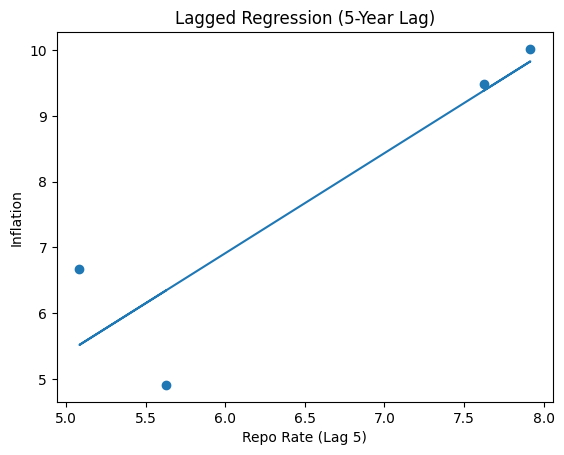

In [12]:
plt.scatter(lagged["Repo_Lag5"], lagged["Inflation"])

plt.plot(
    lagged["Repo_Lag5"],
    model.predict(X),
)

plt.xlabel("Repo Rate (Lag 5)")
plt.ylabel("Inflation")
plt.title("Lagged Regression (5-Year Lag)")

plt.savefig("regression_plot.png")
plt.show()

**Why is your regression weak?**

Due to annual aggregation, the sample size is limited after applying lags. However, the model still demonstrates directional evidence of delayed policy transmission.

## Key Findings

1. Inflation and repo rate exhibit a strong relationship where RBI adjusts rates based on inflation trends.

2. A lag exists between inflation changes and policy action, indicating delayed transmission of monetary policy.

3. External factors such as global economic conditions influence inflation beyond repo rate control.

4. During economic shocks such as the 2008–2009 global financial crisis, repo rates were significantly reduced to stimulate growth, as visible in the dataset.


## Conclusion

This study demonstrates that RBI uses repo rate as an effective tool to manage inflation.

However, the relationship is not immediate due to economic complexities and policy transmission delays.

This analysis highlights the role of data-driven insights in understanding monetary policy dynamics.

## Limitations

- Limited to inflation and repo rate only
- Does not include global economic factors
- Yearly data hides short-term fluctuations

## Future Scope

- Include GDP and unemployment data
- Apply time-series forecasting models
- Analyze monthly policy impact

## Research Summary

This project analyzed the relationship between inflation and RBI monetary policy using real-world datasets.

By applying data cleaning, transformation, and visualization techniques, meaningful insights were derived regarding how RBI responds to inflation.

The analysis confirms that monetary policy is responsive but operates with a transmission lag of approximately 5–6 years, with a contemporaneous correlation of –0.61 between inflation and repo rate.